# Módulo 10 tarefa 03
Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Construa um gráfico de barras para avaliar a distribuição das variáveis qualitativas no tempo. Você acha que houve alguma alteração importante a ser investigada?

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# carregar dados
df = pd.read_csv('previsao_de_renda.csv')

# remover coluna desnecessária
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# transformar data
df['data_ref'] = pd.to_datetime(df['data_ref'])

# extrair mês (ou ano/mês)
df['mes'] = df['data_ref'].dt.to_period('M').astype(str)

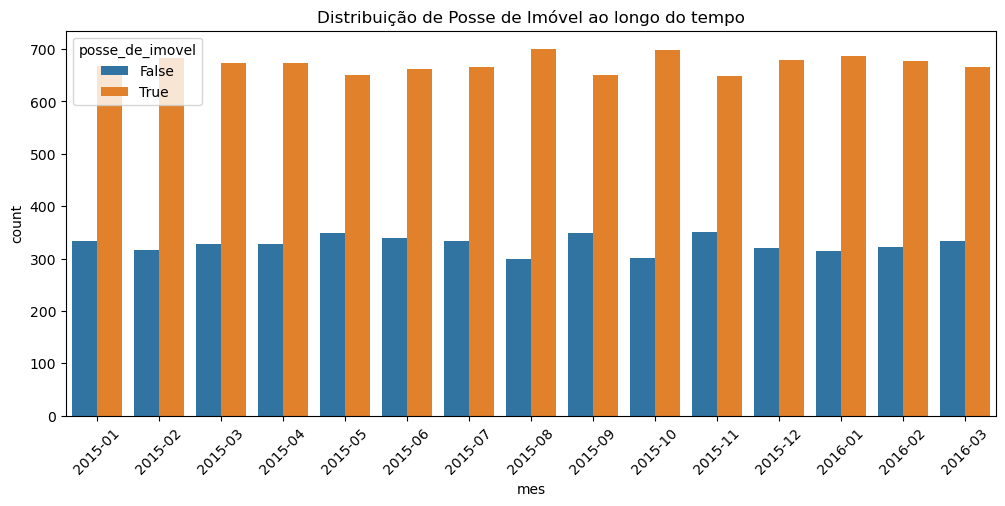

In [20]:
#Posse de imóvel
plt.figure(figsize=(12,5))
sns.countplot(x='mes', hue='posse_de_imovel', data=df)
plt.xticks(rotation=45)
plt.title('Distribuição de Posse de Imóvel ao longo do tempo')
plt.show()

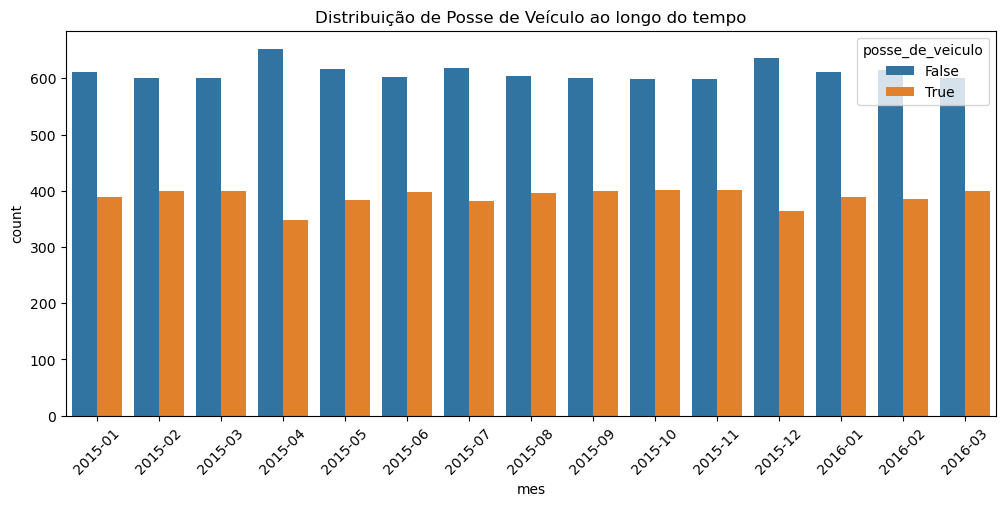

In [22]:
#Posse de imóvel
plt.figure(figsize=(12,5))
sns.countplot(x='mes', hue='posse_de_veiculo', data=df)
plt.xticks(rotation=45)
plt.title('Distribuição de Posse de Veículo ao longo do tempo')
plt.show()

2) Para cada variável qualitativa, construa um gráfico mostrando as médias de cada nível da variável no tempo e avalie a estabilidade. Houve alguma alteração importante? Você acha que se pode utilizar essas variáveis em uma modelagem?

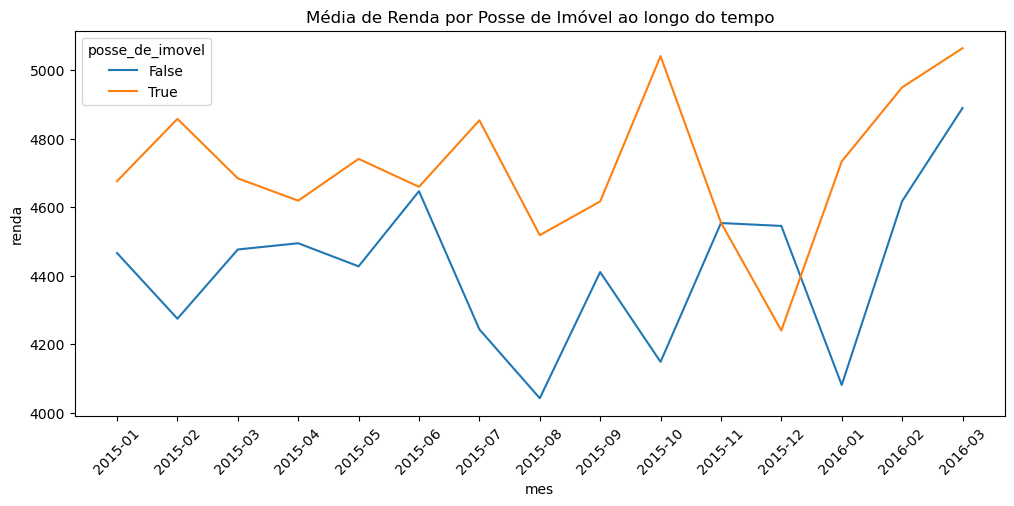

In [24]:
# Imovel
media_imovel = df.groupby(['mes', 'posse_de_imovel'])['renda'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(x='mes', y='renda', hue='posse_de_imovel', data=media_imovel)
plt.xticks(rotation=45)
plt.title('Média de Renda por Posse de Imóvel ao longo do tempo')
plt.show()

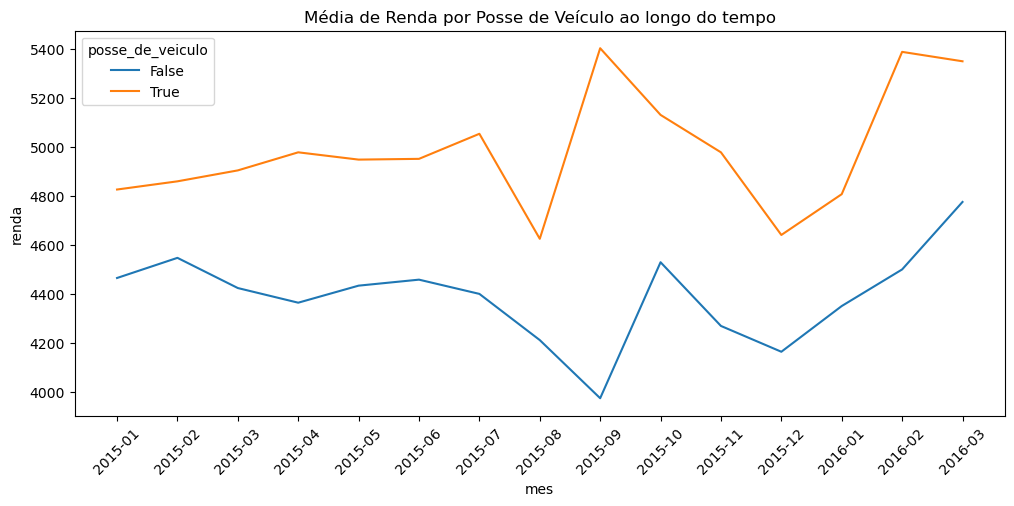

In [26]:
# Veículo
media_veiculo = df.groupby(['mes', 'posse_de_veiculo'])['renda'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(x='mes', y='renda', hue='posse_de_veiculo', data=media_veiculo)
plt.xticks(rotation=45)
plt.title('Média de Renda por Posse de Veículo ao longo do tempo')
plt.show()

De modo geral, as variáveis qualitativas analisadas apresentam comportamento estável ao longo do tempo, o que é positivo para modelagem. No entanto, o poder discriminatório individual dessas variáveis é limitado, sendo mais adequado utilizá-las em conjunto com outras variáveis explicativas.